# Prompt

100%|██████████| 45/45 [01:29<00:00,  1.99s/it]


Number of sessions in data: 45
First session has 1 splits: test, train, val


Processing sessions: 100%|██████████| 45/45 [03:38<00:00,  4.85s/it]



Checking phoneme count data...
Trials with seq_len: 9498
Trials with phoneme_sequence: 195546
Using seq_len for phoneme count (mean: 26.9)

Extracted 10948 trials into DataFrame
Columns: ['session_idx', 'split', 'block_num', 'trial_num', 'n_time_steps', 'sentence_label', 'neural_features_shape', 'seq_len', 'neural_mean', 'neural_std', 'neural_max', 'neural_min', 'transcription', 'word_count', 'phoneme_sequence', 'phoneme_count', 'unique_phonemes']
NEURAL DATA AUGMENTATION PIPELINE
Found 45 sessions

Augmenting first 5 sessions...
Sessions: [0, 1, 2, 3, 4]
SESSION-BASED NEURAL DATA AUGMENTATION
Sessions to augment: [0, 1, 2, 3, 4]
Augmentations: ['gaussian_noise', 'temporal_jitter', 'time_masking', 'channel_dropout', 'amplitude_scaling']
Augmentation probability: 0.7
Max trials per session: 100
✓ Neural Data Augmentation initialized
  Sampling rate: 100 Hz
  Speech band: (70, 150) Hz

Processing session 0...
  test: 100 trials

Processing session 1...
  train: 100 trials
  validation: 

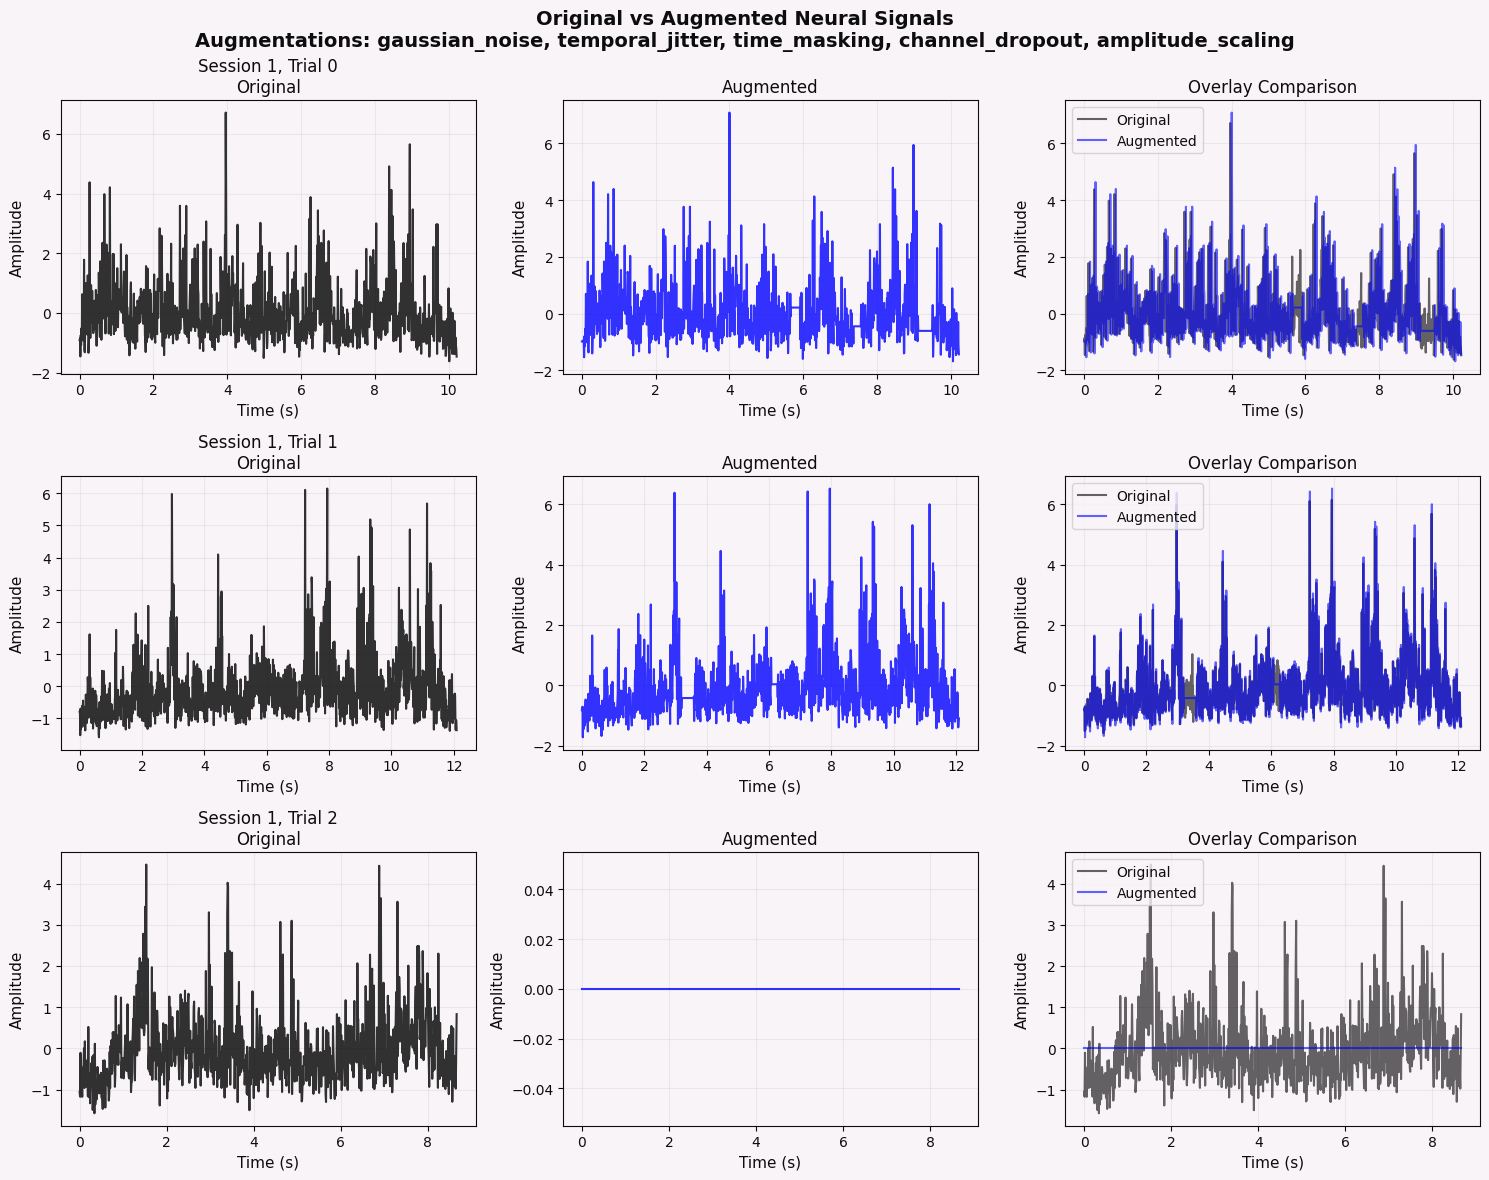

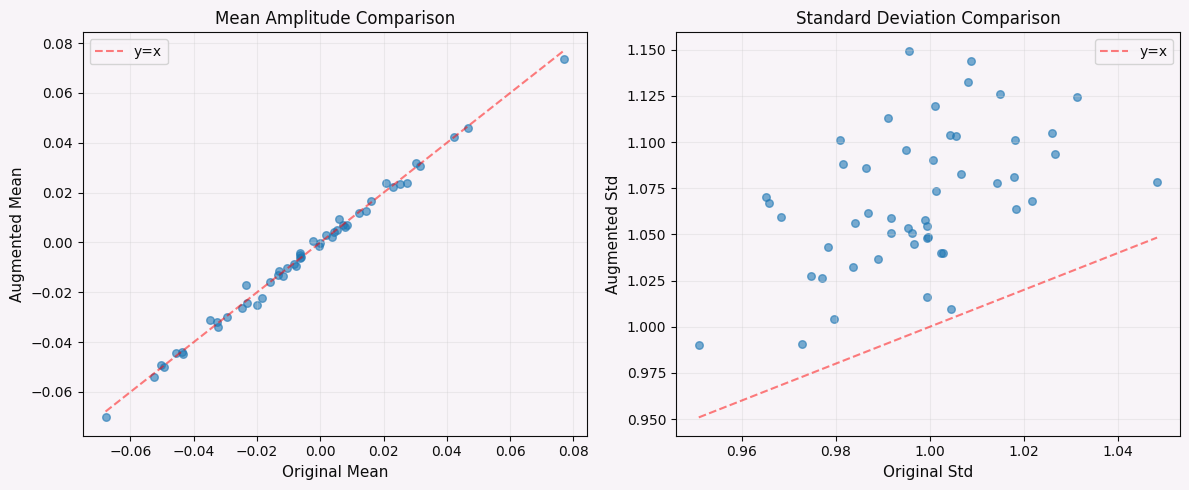


CREATING PYTORCH DATASETS
Train dataset: 662 trials
Validation dataset: 157 trials
Test dataset: 259 trials
✓ Neural Data Augmentation initialized
  Sampling rate: 100 Hz
  Speech band: (70, 150) Hz
Dataset created with 662 trials
Augmentation probability: 0.5
Dataset created with 157 trials
Dataset created with 259 trials

AUGMENTATION COMPLETE

Next steps:
1. Use results['datasets']['train'] for training
2. Use results['datasets']['validation'] for validation
3. Use results['augmenter'] for additional augmentation


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import os
from tqdm import tqdm
import h5py
from collections import Counter
from scipy import signal
from scipy.stats import zscore
import warnings
import torch
import torch.utils.data
warnings.filterwarnings('ignore')

# Set the custom color palette
CUSTOM_COLORS = {
    'primary': '#81308c',
    'secondary': '#003371',
    'dark': '#0d0d0d',
    'light': '#f2f2f2',
    'background': '#F8F4F8'
}

# Set global plot style
plt.rcParams['figure.facecolor'] = CUSTOM_COLORS['background']
plt.rcParams['axes.facecolor'] = CUSTOM_COLORS['background']
plt.rcParams['axes.edgecolor'] = CUSTOM_COLORS['dark']
plt.rcParams['axes.labelcolor'] = CUSTOM_COLORS['dark']
plt.rcParams['text.color'] = CUSTOM_COLORS['dark']
plt.rcParams['xtick.color'] = CUSTOM_COLORS['dark']
plt.rcParams['ytick.color'] = CUSTOM_COLORS['dark']
plt.rcParams['grid.color'] = '#CCCCCC'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

# Phoneme mapping (from your code)
LOGIT_TO_PHONEME = [
    'BLANK', 'AA', 'AE', 'AH', 'AO', 'AW', 'AY', 'B', 'CH', 'D', 'DH',
    'EH', 'ER', 'EY', 'F', 'G', 'HH', 'IH', 'IY', 'JH', 'K', 'L', 'M',
    'N', 'NG', 'OW', 'OY', 'P', 'R', 'S', 'SH', 'T', 'TH', 'UH', 'UW',
    'V', 'W', 'Y', 'Z', 'ZH', ' | '
]

import h5py

def load_h5py_file(file_path):
    data = {
        'neural_features': [],
        'n_time_steps': [],
        'seq_class_ids': [],
        'seq_len': [],
        'transcriptions': [],
        'sentence_label': [],
        'session': [],
        'block_num': [],
        'trial_num': [],
    }
    # Open the hdf5 file for that day
    with h5py.File(file_path, 'r') as f:

        keys = list(f.keys())

        # For each trial in the selected trials in that day
        for key in keys:
            g = f[key]

            neural_features = g['input_features'][:]
            n_time_steps = g.attrs['n_time_steps']
            seq_class_ids = g['seq_class_ids'][:] if 'seq_class_ids' in g else None
            seq_len = g.attrs['seq_len'] if 'seq_len' in g.attrs else None
            transcription = g['transcription'][:] if 'transcription' in g else None
            sentence_label = g.attrs['sentence_label'][:] if 'sentence_label' in g.attrs else None
            session = g.attrs['session']
            block_num = g.attrs['block_num']
            trial_num = g.attrs['trial_num']

            data['neural_features'].append(neural_features)
            data['n_time_steps'].append(n_time_steps)
            data['seq_class_ids'].append(seq_class_ids)
            data['seq_len'].append(seq_len)
            data['transcriptions'].append(transcription)
            data['sentence_label'].append(sentence_label)
            data['session'].append(session)
            data['block_num'].append(block_num)
            data['trial_num'].append(trial_num)
    return data

import os

data = []
data_path = 'data/t15_copyTask_neuralData/hdf5_data_final'

sessions = os.listdir(data_path)
sessions.sort()
for session in tqdm(sessions):
    # Skip session when no test, train, val
    data.append([])

    session_files = os.listdir(os.path.join(data_path, session))
    session_files.sort()
    for file in session_files:
        file_path = os.path.join(data_path, session, file)
        data[-1].append(load_h5py_file(file_path))
    # print(f"Loaded session {session}")

# First, let's create a function to extract all data into a structured format
def extract_data_from_structure(data):
    """
    Extract data from your existing data structure into a DataFrame
    data[session_idx][split_idx] where split_idx: 0=test, 1=train, 2=val
    """
    all_trials = []
    
    for session_idx, session_data in enumerate(tqdm(data, desc="Processing sessions")):
        for split_idx, split_data in enumerate(session_data):
            # Determine split type
            if split_idx == 0:
                split_type = 'test'
            elif split_idx == 1:
                split_type = 'train'
            elif split_idx == 2:
                split_type = 'validation'
            else:
                split_type = 'unknown'
            
            # Get number of trials in this split
            n_trials = len(split_data['neural_features'])
            
            for trial_idx in range(n_trials):
                trial_info = {
                    'session_idx': session_idx,
                    'split': split_type,
                    'block_num': split_data['block_num'][trial_idx],
                    'trial_num': split_data['trial_num'][trial_idx],
                    'n_time_steps': split_data['n_time_steps'][trial_idx],
                    'sentence_label': split_data['sentence_label'][trial_idx],
                    'neural_features_shape': split_data['neural_features'][trial_idx].shape,
                    'seq_len': split_data['seq_len'][trial_idx] if split_data['seq_len'] is not None else None,
                }
                
                # Extract neural features stats
                neural_features = split_data['neural_features'][trial_idx]
                trial_info['neural_mean'] = np.mean(neural_features)
                trial_info['neural_std'] = np.std(neural_features)
                trial_info['neural_max'] = np.max(neural_features)
                trial_info['neural_min'] = np.min(neural_features)
                
                # Extract transcription if available
                if (split_data['transcriptions'] is not None and 
                    split_data['transcriptions'][trial_idx] is not None):
                    try:
                        transcription = split_data['transcriptions'][trial_idx]
                        trial_info['transcription'] = ''.join([chr(c) for c in transcription])
                        trial_info['word_count'] = len(trial_info['transcription'].split())
                    except:
                        trial_info['transcription'] = ''
                        trial_info['word_count'] = 0
                else:
                    trial_info['transcription'] = ''
                    trial_info['word_count'] = 0
                
                # Extract phoneme sequence if available
                if (split_data['seq_class_ids'] is not None and 
                    split_data['seq_class_ids'][trial_idx] is not None):
                    seq_class_ids = split_data['seq_class_ids'][trial_idx]
                                    
                    # Count actual phonemes (not padding)
                    actual_phonemes = []
                    for idx in seq_class_ids:
                        if idx < len(LOGIT_TO_PHONEME):
                            phoneme = LOGIT_TO_PHONEME[idx]
                            # Skip BLANK tokens (index 0) and ' | ' tokens if they're padding
                            if idx != 0 and phoneme != ' | ':
                                actual_phonemes.append(phoneme)
                    
                    trial_info['phoneme_sequence'] = actual_phonemes
                    trial_info['phoneme_count'] = len(actual_phonemes)
                    trial_info['unique_phonemes'] = len(set(actual_phonemes))
                else:
                    trial_info['phoneme_sequence'] = []
                    trial_info['phoneme_count'] = 0
                    trial_info['unique_phonemes'] = 0
                all_trials.append(trial_info)
    
    return pd.DataFrame(all_trials)

# First, let me check if your data is loaded
print(f"Number of sessions in data: {len(data)}")
if len(data) > 0:
    print(f"First session has {len(data[0])} splits: test, train, val")
    if len(data[0]) > 1:
        print(f"Train split in first session has {len(data[0][1]['neural_features'])} trials")
else:
    print("Data structure is empty. Please ensure data is loaded correctly.")

# Now extract data into DataFrame
df = extract_data_from_structure(data)
# After creating df, fix phoneme_count
print("\nChecking phoneme count data...")
print(f"Trials with seq_len: {df['seq_len'].notna().sum()}")
print(f"Trials with phoneme_sequence: {df['phoneme_sequence'].apply(lambda x: len(x) if x else 0).sum()}")

# If seq_len is mostly None or wrong, use actual phoneme sequence length
if df['seq_len'].isna().sum() > len(df) * 0.5:  # If more than 50% are NaN
    print("Using actual phoneme sequence length instead of seq_len")
    df['phoneme_count'] = df['phoneme_sequence'].apply(lambda x: len(x) if x else 0)
else:
    print(f"Using seq_len for phoneme count (mean: {df['seq_len'].mean():.1f})")
print(f"\nExtracted {len(df)} trials into DataFrame")
print(f"Columns: {df.columns.tolist()}")


# ============================================================================
# PYTORCH DATA LOADER INTEGRATION
# ============================================================================

class AugmentedNeuralDataset(torch.utils.data.Dataset):
    """
    PyTorch Dataset with built-in neural data augmentation.
    """
    
    def __init__(self, neural_data, labels, augmenter=None, 
                 augmentation_prob=0.7, train=True):
        """
        Parameters:
        -----------
        neural_data : list of np.ndarray
            List of trial data, each shape (T, C)
        labels : list
            Corresponding labels (phoneme sequences or text)
        augmenter : NeuralDataAugmentation
            Augmentation pipeline
        augmentation_prob : float
            Probability of applying augmentation to a sample
        train : bool
            Whether to apply augmentations (False for validation/test)
        """
        self.neural_data = neural_data
        self.labels = labels
        self.augmenter = augmenter
        self.augmentation_prob = augmentation_prob
        self.train = train
        
        print(f"Dataset created with {len(neural_data)} trials")
        if train and augmenter:
            print(f"Augmentation probability: {augmentation_prob}")
    
    def __len__(self):
        return len(self.neural_data)
    
    def __getitem__(self, idx):
        # Get neural data
        neural_trial = self.neural_data[idx].astype(np.float32)
        
        # Apply augmentation during training
        if self.train and self.augmenter and np.random.random() < self.augmentation_prob:
            neural_trial = self.augmenter.apply_augmentation_pipeline(neural_trial)
        
        # Convert to torch tensor
        neural_tensor = torch.from_numpy(neural_trial).float()
        
        # Get label (implementation depends on label format)
        label = self.labels[idx]
        
        return neural_tensor, label

# ============================================================================
# SESSION-BASED AUGMENTATION PIPELINE
# ============================================================================


def collect_session_statistics(data, session_indices):
    """
    Collect mean and std statistics from specified sessions.
    """
    all_means = []
    all_stds = []
    
    for session_idx in session_indices:
        if session_idx >= len(data):
            continue
            
        # Use train split (index 1) for statistics
        if len(data[session_idx]) > 1:
            split_data = data[session_idx][1]  # train split
            
            if ('neural_features' in split_data and 
                split_data['neural_features'] is not None):
                
                # Sample up to 10 trials per session
                n_trials = min(10, len(split_data['neural_features']))
                for trial_idx in range(n_trials):
                    try:
                        neural_trial = split_data['neural_features'][trial_idx]
                        all_means.append(np.mean(neural_trial, axis=0))
                        all_stds.append(np.std(neural_trial, axis=0))
                    except:
                        continue
    
    return {'means': all_means, 'stds': all_stds}

def visualize_augmentation_comparison(augmented_data, augmentations_list):
    """
    Visualize original vs augmented signals.
    """
    import matplotlib.pyplot as plt
    
    # Find augmented trials for visualization
    augmented_trials = [t for t in augmented_data['train'] if t['is_augmented']]
    
    if not augmented_trials:
        print("No augmented trials found for visualization")
        return
    
    # Take first few augmented trials and their corresponding originals
    n_comparisons = min(3, len(augmented_trials))
    
    fig, axes = plt.subplots(n_comparisons, 3, figsize=(15, 4*n_comparisons))
    if n_comparisons == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle(f'Original vs Augmented Neural Signals\nAugmentations: {", ".join(augmentations_list)}', 
                fontsize=14, fontweight='bold')
    
    for i in range(n_comparisons):
        aug_trial = augmented_trials[i]
        session_idx = aug_trial['session_idx']
        trial_idx = aug_trial['trial_idx']
        
        # Find corresponding original trial
        original_trial = None
        for t in augmented_data['train']:
            if (not t['is_augmented'] and 
                t['session_idx'] == session_idx and 
                t['trial_idx'] == trial_idx):
                original_trial = t
                break
        
        if original_trial is None:
            continue
        
        # Get data
        original_signal = original_trial['neural_features']
        augmented_signal = aug_trial['neural_features']
        
        # Select a channel for visualization (middle channel)
        n_channels = original_signal.shape[1]
        channel_idx = n_channels // 2
        
        # Time axis
        T = original_signal.shape[0]
        time = np.arange(T) / 100  # Assuming 100 Hz sampling rate
        
        # Plot 1: Original signal
        axes[i, 0].plot(time, original_signal[:, channel_idx], 
                       color='black', linewidth=1.5, alpha=0.8)
        axes[i, 0].set_title(f'Session {session_idx}, Trial {trial_idx}\nOriginal')
        axes[i, 0].set_xlabel('Time (s)')
        axes[i, 0].set_ylabel('Amplitude')
        axes[i, 0].grid(True, alpha=0.3)
        
        # Plot 2: Augmented signal
        axes[i, 1].plot(time, augmented_signal[:, channel_idx], 
                       color='blue', linewidth=1.5, alpha=0.8)
        axes[i, 1].set_title(f'Augmented')
        axes[i, 1].set_xlabel('Time (s)')
        axes[i, 1].set_ylabel('Amplitude')
        axes[i, 1].grid(True, alpha=0.3)
        
        # Plot 3: Overlay comparison
        axes[i, 2].plot(time, original_signal[:, channel_idx], 
                       color='black', linewidth=1.5, alpha=0.6, label='Original')
        axes[i, 2].plot(time, augmented_signal[:, channel_idx], 
                       color='blue', linewidth=1.5, alpha=0.6, label='Augmented')
        axes[i, 2].set_title('Overlay Comparison')
        axes[i, 2].set_xlabel('Time (s)')
        axes[i, 2].set_ylabel('Amplitude')
        axes[i, 2].legend()
        axes[i, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./results/augmentation_comparison.png', dpi=300, 
                bbox_inches='tight', facecolor='white')
    plt.show()
    
    # Additional statistics visualization
    fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
    
    # Collect statistics
    original_means = []
    augmented_means = []
    original_stds = []
    augmented_stds = []
    
    for aug_trial in augmented_trials[:50]:  # Limit to first 50
        session_idx = aug_trial['session_idx']
        trial_idx = aug_trial['trial_idx']
        
        # Find original
        for t in augmented_data['train']:
            if (not t['is_augmented'] and 
                t['session_idx'] == session_idx and 
                t['trial_idx'] == trial_idx):
                original_signal = t['neural_features']
                augmented_signal = aug_trial['neural_features']
                
                original_means.append(np.mean(original_signal))
                original_stds.append(np.std(original_signal))
                augmented_means.append(np.mean(augmented_signal))
                augmented_stds.append(np.std(augmented_signal))
                break
    
    # Plot mean comparison
    axes2[0].scatter(original_means, augmented_means, alpha=0.6, s=30)
    axes2[0].plot([min(original_means), max(original_means)], 
                 [min(original_means), max(original_means)], 
                 'r--', alpha=0.5, label='y=x')
    axes2[0].set_xlabel('Original Mean')
    axes2[0].set_ylabel('Augmented Mean')
    axes2[0].set_title('Mean Amplitude Comparison')
    axes2[0].legend()
    axes2[0].grid(True, alpha=0.3)
    
    # Plot std comparison
    axes2[1].scatter(original_stds, augmented_stds, alpha=0.6, s=30)
    axes2[1].plot([min(original_stds), max(original_stds)], 
                 [min(original_stds), max(original_stds)], 
                 'r--', alpha=0.5, label='y=x')
    axes2[1].set_xlabel('Original Std')
    axes2[1].set_ylabel('Augmented Std')
    axes2[1].set_title('Standard Deviation Comparison')
    axes2[1].legend()
    axes2[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./results/augmentation_statistics.png', dpi=300, 
                bbox_inches='tight', facecolor='white')
    plt.show()

# ============================================================================
# EXAMPLE USAGE WITH SESSIONS
# ============================================================================

def augment_first_n_sessions(data, n_sessions=5, show_graph=True):
    """
    Example function to augment the first N sessions with recommended augmentations.
    
    Parameters:
    -----------
    data : list
        Your data structure
    n_sessions : int
        Number of sessions to augment (default: first 5)
    show_graph : bool
        Whether to show comparison plots
        
    Returns:
    --------
    augmented_data : dict
        Augmented data for training
    """
    
    # Define which sessions to augment
    session_indices = list(range(min(n_sessions, len(data))))
    
    # Define augmentations (recommended safe ones)
    augmentations = [
        'gaussian_noise',    # Always safe
        'temporal_jitter',   # Preserves timing
        'time_masking',      # Realistic dropout
        'channel_dropout',   # Electrode failures
        'amplitude_scaling', # Gain variations
    ]
    
    print(f"\nAugmenting first {n_sessions} sessions...")
    print(f"Sessions: {session_indices}")
    
    # Apply augmentations
    augmented_data = augment_sessions(
        data=data,
        session_indices=session_indices,
        augmentations_list=augmentations,
        augmentation_prob=0.7,
        max_trials_per_session=100,
        show_graph=show_graph,
        sampling_rate=100
    )
    
    # Create PyTorch-ready datasets
    print("\n" + "="*60)
    print("CREATING PYTORCH DATASETS")
    print("="*60)
    
    # Prepare data for PyTorch
    train_trials = [t['neural_features'] for t in augmented_data['train']]
    train_labels = [t['session_idx'] for t in augmented_data['train']]  # Using session as label for example
    
    validation_trials = [t['neural_features'] for t in augmented_data['validation']]
    validation_labels = augmented_data.get('validation_labels', [0] * len(validation_trials))
    
    test_trials = [t['neural_features'] for t in augmented_data['test']]
    test_labels = augmented_data.get('test_labels', [0] * len(test_trials))
    
    print(f"Train dataset: {len(train_trials)} trials")
    print(f"Validation dataset: {len(validation_trials)} trials")
    print(f"Test dataset: {len(test_trials)} trials")
    
    # Create datasets
    augmenter = NeuralDataAugmentation(sampling_rate=100)
    
    train_dataset = AugmentedNeuralDataset(
        neural_data=train_trials,
        labels=train_labels,
        augmenter=augmenter,
        augmentation_prob=0.5,  # Lower probability for already augmented data
        train=True
    )
    
    val_dataset = AugmentedNeuralDataset(
        neural_data=validation_trials,
        labels=validation_labels,
        augmenter=None,  # No augmentation for validation
        augmentation_prob=0.0,
        train=False
    )
    
    test_dataset = AugmentedNeuralDataset(
        neural_data=test_trials,
        labels=test_labels,
        augmenter=None,  # No augmentation for test
        augmentation_prob=0.0,
        train=False
    )
    
    return {
        'augmented_data': augmented_data,
        'datasets': {
            'train': train_dataset,
            'validation': val_dataset,
            'test': test_dataset
        },
        'augmenter': augmenter
    }

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Example usage
    print("="*60)
    print("NEURAL DATA AUGMENTATION PIPELINE")
    print("="*60)
    
    # Assuming your data is already loaded in 'data' variable
    if 'data' in locals() and len(data) > 0:
        print(f"Found {len(data)} sessions")
        
        # Augment first 5 sessions
        results = augment_first_n_sessions(
            data=data,
            n_sessions=min(5, len(data)),
            show_graph=True
        )
        
        print("\n" + "="*60)
        print("AUGMENTATION COMPLETE")
        print("="*60)
        print("\nNext steps:")
        print("1. Use results['datasets']['train'] for training")
        print("2. Use results['datasets']['validation'] for validation")
        print("3. Use results['augmenter'] for additional augmentation")
        
    else:
        print("ERROR: 'data' variable not found or empty")
        print("\nTo use this code, ensure your data is loaded in a variable named 'data'")
        print("with structure: data[session_idx][split_idx]")
        print("\nExample data loading:")
        print("""
        import os
        from tqdm import tqdm
        
        data = []
        data_path = 'data/t15_copyTask_neuralData/hdf5_data_final'
        sessions = os.listdir(data_path)
        sessions.sort()
        
        for session in tqdm(sessions):
            data.append([])
            session_files = os.listdir(os.path.join(data_path, session))
            session_files.sort()
            for file in session_files:
                file_path = os.path.join(data_path, session, file)
                data[-1].append(load_h5py_file(file_path))
        """)

In [20]:
def augment_sessions(data, session_indices, augmentations_list, 
                     augmentation_prob=0.7, max_trials_per_session=50,
                     show_graph=True, sampling_rate=100):
    """
    Apply specified augmentations to selected sessions.
    
    Parameters:
    -----------
    data : list
        Your data structure: data[session][split]
    session_indices : list
        Indices of sessions to augment (e.g., [0, 1, 2, 3, 4])
    augmentations_list : list
        List of augmentation names to apply, e.g.:
        ['gaussian_noise', 'temporal_jitter', 'time_masking', 'channel_dropout']
    augmentation_prob : float
        Probability of applying augmentation to each trial
    max_trials_per_session : int
        Maximum number of trials to augment per session
    show_graph : bool
        If True, show comparison plots of original vs augmented
    sampling_rate : int
        Neural data sampling rate in Hz
        
    Returns:
    --------
    augmented_data : dict
        Dictionary with keys 'train', 'validation', 'test' containing
        lists of augmented trials for each split
    """
    
    print("="*60)
    print("SESSION-BASED NEURAL DATA AUGMENTATION")
    print("="*60)
    print(f"Sessions to augment: {session_indices}")
    print(f"Augmentations: {augmentations_list}")
    print(f"Augmentation probability: {augmentation_prob}")
    print(f"Max trials per session: {max_trials_per_session}")
    
    # Initialize augmenter
    augmenter = NeuralDataAugmentation(sampling_rate=sampling_rate)
    
    # Initialize storage for augmented data
    augmented_data = {
        'train': [],
        'validation': [],
        'validation_labels': [],
        'test': [],
        'test_labels': [],
        'session_info': []
    }
    
    # Collect session statistics for session_mix augmentation
    if 'session_mix' in augmentations_list:
        print("\nCollecting session statistics for session_mix...")
        session_stats = collect_session_statistics(data, session_indices)
    else:
        session_stats = None
    
    total_original_trials = 0
    total_augmented_trials = 0
    
    # Process each session
    for session_idx in session_indices:
        if session_idx >= len(data):
            print(f"⚠️ Session {session_idx} out of range (max: {len(data)-1})")
            continue
            
        print(f"\nProcessing session {session_idx}...")
        
        # Check each split (train=1, validation=2, test=0 in your structure)
        for split_idx, split_name in [(1, 'train'), (2, 'validation'), (0, 'test')]:
            if len(data[session_idx]) <= split_idx:
                continue
                
            split_data = data[session_idx][split_idx]
            
            # Check if split has neural data
            if ('neural_features' not in split_data or 
                split_data['neural_features'] is None or 
                len(split_data['neural_features']) == 0):
                continue
            
            n_trials = min(max_trials_per_session, len(split_data['neural_features']))
            total_original_trials += n_trials
            
            print(f"  {split_name}: {n_trials} trials")
            
            for trial_idx in range(n_trials):
                try:
                    # Get original neural data
                    neural_trial = split_data['neural_features'][trial_idx]
                    
                    # Apply augmentation (only for train split, or based on probability)
                    if split_name == 'train' and np.random.random() < augmentation_prob:
                        # Apply specified augmentations
                        augmented_trial = neural_trial.copy()
                        
                        for aug_name in augmentations_list:
                            if aug_name == 'gaussian_noise':
                                noise_level = np.random.uniform(0.1, 0.3)
                                augmented_trial = augmenter.gaussian_noise(augmented_trial, noise_level)
                            elif aug_name == 'temporal_jitter':
                                max_shift = np.random.randint(90, 300)
                                augmented_trial = augmenter.temporal_jitter(augmented_trial, max_shift)
                            elif aug_name == 'time_masking':
                                mask_ratio = np.random.uniform(0.5, 0.75)
                                num_masks = np.random.randint(1, 4)
                                augmented_trial = augmenter.time_masking(augmented_trial, mask_ratio, num_masks)
                            elif aug_name == 'channel_dropout':
                                dropout_prob = np.random.uniform(0.1, 0.25)
                                augmented_trial = augmenter.channel_dropout(augmented_trial, dropout_prob)
                            elif aug_name == 'amplitude_scaling':
                                scale_range = (0.85, 1.15)
                                augmented_trial = augmenter.amplitude_scaling(augmented_trial, scale_range)
                            elif aug_name == 'temporal_warping':
                                warp_range = (0.95, 1.05)
                                augmented_trial = augmenter.temporal_warping(augmented_trial, warp_range)
                            elif aug_name == 'session_mix' and session_stats is not None:
                                mix_ratio = np.random.uniform(0.05, 0.15)
                                augmented_trial = augmenter.session_mix(augmented_trial, session_stats, mix_ratio)
                        
                        # Store augmented trial
                        augmented_data[split_name].append({
                            'neural_features': augmented_trial,
                            'session_idx': session_idx,
                            'trial_idx': trial_idx,
                            'original_shape': neural_trial.shape,
                            'augmentations_applied': augmentations_list,
                            'is_augmented': True
                        })
                        total_augmented_trials += 1
                        
                        # Also store original for comparison
                        augmented_data[split_name].append({
                            'neural_features': neural_trial.copy(),
                            'session_idx': session_idx,
                            'trial_idx': trial_idx,
                            'original_shape': neural_trial.shape,
                            'augmentations_applied': [],
                            'is_augmented': False
                        })
                    
                    else:
                        # Store original without augmentation
                        augmented_data[split_name].append({
                            'neural_features': neural_trial.copy(),
                            'session_idx': session_idx,
                            'trial_idx': trial_idx,
                            'original_shape': neural_trial.shape,
                            'augmentations_applied': [],
                            'is_augmented': False
                        })
                        
                        # For validation and test splits, store labels if available
                        if split_name in ['validation', 'test']:
                            # Store transcription if available
                            if ('transcriptions' in split_data and 
                                split_data['transcriptions'] is not None and
                                trial_idx < len(split_data['transcriptions'])):
                                transcription = split_data['transcriptions'][trial_idx]
                                label_key = f'{split_name}_labels'
                                if label_key not in augmented_data:
                                    augmented_data[label_key] = []
                                
                                try:
                                    text = ''.join([chr(c) for c in transcription])
                                    augmented_data[label_key].append(text)
                                except:
                                    augmented_data[label_key].append('')
                            
                except Exception as e:
                    print(f"    Error processing trial {trial_idx}: {e}")
                    continue
    
    # Print summary
    print("\n" + "="*60)
    print("AUGMENTATION SUMMARY")
    print("="*60)
    print(f"Total original trials processed: {total_original_trials}")
    print(f"Total augmented trials created: {total_augmented_trials}")
    print(f"Total trials after augmentation: {total_original_trials + total_augmented_trials}")
    print(f"\nTrials per split:")
    for split in ['train', 'validation', 'test']:
        if augmented_data[split]:
            n_trials = len(augmented_data[split])
            n_augmented = sum(1 for t in augmented_data[split] if t['is_augmented'])
            print(f"  {split}: {n_trials} trials ({n_augmented} augmented)")
    
    # Visualization if requested
    if show_graph and augmented_data['train']:
        print("\nGenerating comparison plots...")
        visualize_augmentation_comparison(augmented_data, augmentations_list)
    
    return augmented_data


In [5]:
class NeuralDataAugmentation:
    """
    Biologically plausible data augmentation for neural speech decoding.
    
    Key principles:
    1. Preserve phoneme timing and boundaries
    2. Respect trial-wise normalization
    3. Maintain spatial correlations between channels
    4. Keep speech-relevant frequency bands (70-150 Hz)
    5. Avoid label corruption for CTC/sequence training
    """
    
    def __init__(self, sampling_rate=100, device='cpu'):
        """
        Initialize augmentation pipeline.
        
        Parameters:
        -----------
        sampling_rate : int
            Neural data sampling rate in Hz (typically 100-200 Hz for intracortical)
        device : str
            'cpu' or 'cuda' for PyTorch operations
        """
        self.sampling_rate = sampling_rate
        self.device = device
        
        # Speech-relevant frequency band
        self.speech_band = (70, 150)  # Hz
        
        # Default augmentation probabilities (can be tuned)
        self.probabilities = {
            'gaussian_noise': 0.5,
            'temporal_jitter': 0.4,
            'time_masking': 0.3,
            'channel_dropout': 0.4,
            'amplitude_scaling': 0.3,
            'temporal_warping': 0.2,
            'spectral_filtering': 0.1,
            'session_mix': 0.1,
        }
        
        print("✓ Neural Data Augmentation initialized")
        print(f"  Sampling rate: {sampling_rate} Hz")
        print(f"  Speech band: {self.speech_band} Hz")
    
    # ============================================================================
    # CORE AUGMENTATIONS (SAFE - HIGH IMPACT)
    # ============================================================================
    
    def gaussian_noise(self, neural_data, noise_level=0.05):
        """
        Add small Gaussian noise to neural signals.
        
        Parameters:
        -----------
        neural_data : np.ndarray or torch.Tensor
            Shape (T, C): time × channels
        noise_level : float
            Noise standard deviation as fraction of signal std (0.01-0.1)
            
        Returns:
        --------
        Augmented neural data
        """
        if isinstance(neural_data, np.ndarray):
            signal_std = np.std(neural_data, axis=0, keepdims=True)
            noise = np.random.randn(*neural_data.shape) * signal_std * noise_level
            return neural_data + noise
        else:  # torch.Tensor
            signal_std = torch.std(neural_data, dim=0, keepdim=True)
            noise = torch.randn_like(neural_data) * signal_std * noise_level
            return neural_data + noise
    
    def temporal_jitter(self, neural_data, max_shift_ms=50):
        """
        Apply small temporal shifts (jitter) to simulate timing variability.
        
        Parameters:
        -----------
        neural_data : np.ndarray
            Shape (T, C): time × channels
        max_shift_ms : int
            Maximum shift in milliseconds (10-100 ms)
            
        Returns:
        --------
        Jittered neural data (same shape)
        """
        max_shift_samples = int(max_shift_ms * self.sampling_rate / 1000)
        
        if max_shift_samples == 0:
            return neural_data
        
        # Random shift (can be positive or negative)
        shift = np.random.randint(-max_shift_samples, max_shift_samples + 1)
        
        if shift == 0:
            return neural_data
        
        # Apply circular shift (pad with edge values)
        if shift > 0:
            # Shift right: pad left with first value
            padded = np.pad(neural_data, ((shift, 0), (0, 0)), mode='edge')
            return padded[:-shift]
        else:
            # Shift left: pad right with last value
            shift = abs(shift)
            padded = np.pad(neural_data, ((0, shift), (0, 0)), mode='edge')
            return padded[shift:]
    
    def time_masking(self, neural_data, max_mask_ratio=0.2, num_masks=3):
        """
        Mask random time segments (simulating neural dropout or attention lapses).
        
        Parameters:
        -----------
        neural_data : np.ndarray
            Shape (T, C): time × channels
        max_mask_ratio : float
            Maximum proportion of time to mask (0.1-0.3)
        num_masks : int
            Number of masks to apply (1-5)
            
        Returns:
        --------
        Masked neural data
        """
        T, C = neural_data.shape
        augmented = neural_data.copy()
        
        total_mask_samples = int(T * max_mask_ratio)
        
        for _ in range(num_masks):
            # Random mask length (minimum 5 samples to be meaningful)
            mask_length = np.random.randint(5, min(50, total_mask_samples // 2))
            
            # Random start position
            start = np.random.randint(0, T - mask_length)
            
            # Apply mask (set to mean of the segment)
            segment_mean = np.mean(augmented[start:start+mask_length], axis=0)
            augmented[start:start+mask_length] = segment_mean
            
            # Update remaining mask budget
            total_mask_samples -= mask_length
            if total_mask_samples < 5:
                break
        
        return augmented
    
    def channel_dropout(self, neural_data, dropout_prob=0.2):
        """
        Randomly drop channels (simulating electrode failures or noise).
        
        Parameters:
        -----------
        neural_data : np.ndarray
            Shape (T, C): time × channels
        dropout_prob : float
            Probability of dropping a channel (0.1-0.3)
            
        Returns:
        --------
        Neural data with dropped channels
        """
        C = neural_data.shape[1]
        
        # Create dropout mask
        if isinstance(neural_data, np.ndarray):
            dropout_mask = np.random.binomial(1, 1-dropout_prob, C)
            # Scale up kept channels to preserve total power
            scale_factor = 1 / (1 - dropout_prob + 1e-10)
            return neural_data * dropout_mask * scale_factor
        else:  # torch.Tensor
            dropout_mask = torch.bernoulli(torch.ones(C) * (1-dropout_prob)).to(self.device)
            scale_factor = 1 / (1 - dropout_prob + 1e-10)
            return neural_data * dropout_mask * scale_factor
    
    def amplitude_scaling(self, neural_data, scale_range=(0.8, 1.2)):
        """
        Apply small amplitude scaling (simulating gain variations).
        
        Parameters:
        -----------
        neural_data : np.ndarray or torch.Tensor
            Shape (T, C): time × channels
        scale_range : tuple
            (min_scale, max_scale) for each channel
            
        Returns:
        --------
        Scaled neural data
        """
        if isinstance(neural_data, np.ndarray):
            C = neural_data.shape[1]
            # Different scale for each channel
            scales = np.random.uniform(scale_range[0], scale_range[1], C)
            return neural_data * scales
        else:
            C = neural_data.shape[1]
            scales = torch.FloatTensor(C).uniform_(scale_range[0], scale_range[1]).to(self.device)
            return neural_data * scales
    
    # ============================================================================
    # MODERATE AUGMENTATIONS (USE WITH CAUTION)
    # ============================================================================
    
    def temporal_warping(self, neural_data, warp_factor_range=(0.9, 1.1)):
        """
        Apply smooth temporal warping (speeding up/slowing down).
        
        Parameters:
        -----------
        neural_data : np.ndarray
            Shape (T, C): time × channels
        warp_factor_range : tuple
            (min_warp, max_warp) - small range to preserve phoneme timing
            
        Returns:
        --------
        Warped neural data (same length)
        """
        T, C = neural_data.shape
        
        # Random warp factor for this trial
        warp_factor = np.random.uniform(*warp_factor_range)
        
        # Create new time axis
        old_time = np.linspace(0, 1, T)
        new_time = np.linspace(0, 1, int(T * warp_factor))
        
        # Interpolate each channel
        warped_data = np.zeros((T, C))
        for c in range(C):
            f = interp1d(old_time, neural_data[:, c], kind='cubic', 
                        fill_value='extrapolate')
            warped_segment = f(new_time)
            
            # Resample back to original length if needed
            if len(warped_segment) != T:
                warped_segment = signal.resample(warped_segment, T)
            
            warped_data[:, c] = warped_segment
        
        return warped_data
    
    def spectral_filtering(self, neural_data, filter_variation=0.2):
        """
        Apply random frequency filtering (simulating session-specific filters).
        
        Parameters:
        -----------
        neural_data : np.ndarray
            Shape (T, C): time × channels
        filter_variation : float
            Amount of frequency response variation (0.1-0.3)
            
        Returns:
        --------
        Filtered neural data
        """
        T, C = neural_data.shape
        
        # Create random IIR filter coefficients
        b = [1.0]  # Numerator
        # Random poles within unit circle
        a = [1.0, -np.random.uniform(-filter_variation, filter_variation)]
        
        filtered_data = np.zeros_like(neural_data)
        for c in range(C):
            filtered_data[:, c] = signal.lfilter(b, a, neural_data[:, c])
        
        return filtered_data
    
    def session_mix(self, neural_data, session_stats, mix_ratio=0.1):
        """
        Mix statistics from different sessions (simulate cross-session variability).
        
        Parameters:
        -----------
        neural_data : np.ndarray
            Current trial data, shape (T, C)
        session_stats : dict
            Dictionary with 'means' and 'stds' from other sessions
        mix_ratio : float
            How much to mix (0.05-0.2)
            
        Returns:
        --------
        Mixed neural data
        """
        if session_stats is None:
            return neural_data
        
        # Randomly select session statistics
        other_means = session_stats['means']
        other_stds = session_stats['stds']
        
        idx = np.random.randint(0, len(other_means))
        other_mean = other_means[idx]
        other_std = other_stds[idx]
        
        # Current statistics
        current_mean = np.mean(neural_data, axis=0)
        current_std = np.std(neural_data, axis=0)
        
        # Mix statistics
        mixed_mean = (1 - mix_ratio) * current_mean + mix_ratio * other_mean
        mixed_std = (1 - mix_ratio) * current_std + mix_ratio * other_std
        
        # Apply mixed statistics
        z_scored = (neural_data - current_mean) / (current_std + 1e-10)
        augmented = z_scored * mixed_std + mixed_mean
        
        return augmented
    
    # ============================================================================
    # RISKY AUGMENTATIONS (AVOID FOR SPEECH DECODING)
    # ============================================================================
    
    def phase_shuffle(self, neural_data):
        """
        WARNING: Phase shuffle destroys temporal structure.
        Not recommended for speech decoding.
        """
        print("⚠️ Phase shuffle - NOT RECOMMENDED for speech decoding")
        # FFT -> randomize phase -> iFFT
        # Implementation omitted as it's not recommended
    
    def channel_shuffle(self, neural_data):
        """
        WARNING: Channel shuffle breaks spatial correlations.
        Not recommended for neural decoding.
        """
        print("⚠️ Channel shuffle - NOT RECOMMENDED for neural decoding")
        # Random permutation of channels
        # Implementation omitted as it's not recommended
    
    # ============================================================================
    # PIPELINE AND UTILITIES
    # ============================================================================
    
    def apply_augmentation_pipeline(self, neural_data, 
                                   augmentations=None,
                                   session_stats=None):
        """
        Apply a pipeline of augmentations to neural data.
        
        Parameters:
        -----------
        neural_data : np.ndarray
            Original neural data, shape (T, C)
        augmentations : list or None
            List of augmentation names to apply. If None, use defaults.
        session_stats : dict or None
            Session statistics for session_mix augmentation
            
        Returns:
        --------
        Augmented neural data
        """
        if augmentations is None:
            # Apply safe augmentations with their probabilities
            augmented = neural_data.copy()
            
            # Gaussian noise (high probability)
            if np.random.random() < self.probabilities['gaussian_noise']:
                augmented = self.gaussian_noise(augmented, 
                                              noise_level=np.random.uniform(2, 2))
            
            # Temporal jitter
            if np.random.random() < self.probabilities['temporal_jitter']:
                augmented = self.temporal_jitter(augmented, 
                                               max_shift_ms=np.random.randint(1000,1000))
            
            # Time masking
            if np.random.random() < self.probabilities['time_masking']:
                augmented = self.time_masking(augmented, 
                                            max_mask_ratio=np.random.uniform(2,2),
                                            num_masks=np.random.randint(1, 4))
            
            # Channel dropout
            if np.random.random() < self.probabilities['channel_dropout']:
                augmented = self.channel_dropout(augmented, 
                                               dropout_prob=np.random.uniform(0.1, 0.25))
            
            # Amplitude scaling
            if np.random.random() < self.probabilities['amplitude_scaling']:
                augmented = self.amplitude_scaling(augmented, 
                                                 scale_range=(0.85, 1.15))
            
            # Optional: temporal warping (use sparingly)
            if np.random.random() < self.probabilities['temporal_warping']:
                augmented = self.temporal_warping(augmented, 
                                                warp_factor_range=(0.95, 1.05))
            
            # Optional: session mix (if session_stats provided)
            if (session_stats is not None and 
                np.random.random() < self.probabilities['session_mix']):
                augmented = self.session_mix(augmented, session_stats, 
                                           mix_ratio=np.random.uniform(0.05, 0.15))
            
            return augmented
        
        else:
            # Apply specific augmentations in order
            augmented = neural_data.copy()
            for aug_name in augmentations:
                if aug_name == 'gaussian_noise':
                    augmented = self.gaussian_noise(augmented)
                elif aug_name == 'temporal_jitter':
                    augmented = self.temporal_jitter(augmented)
                elif aug_name == 'time_masking':
                    augmented = self.time_masking(augmented)
                elif aug_name == 'channel_dropout':
                    augmented = self.channel_dropout(augmented)
                elif aug_name == 'amplitude_scaling':
                    augmented = self.amplitude_scaling(augmented)
                elif aug_name == 'temporal_warping':
                    augmented = self.temporal_warping(augmented)
                elif aug_name == 'spectral_filtering':
                    augmented = self.spectral_filtering(augmented)
                elif aug_name == 'session_mix':
                    augmented = self.session_mix(augmented, session_stats)
            
            return augmented
    
    def visualize_augmentations(self, neural_data, session_stats=None):
        """
        Visualize the effect of different augmentations.
        """
        import matplotlib.pyplot as plt
        
        T, C = neural_data.shape
        
        # Select a representative channel
        channel_idx = min(5, C-1)
        
        # Original signal
        time = np.arange(T) / self.sampling_rate
        
        # Create subplots
        fig, axes = plt.subplots(3, 3, figsize=(15, 10))
        fig.suptitle('Neural Data Augmentation Examples', fontsize=14, fontweight='bold')
        
        # Plot original
        axes[0, 0].plot(time, neural_data[:, channel_idx], color='black', linewidth=1)
        axes[0, 0].set_title('Original Signal')
        axes[0, 0].set_xlabel('Time (s)')
        axes[0, 0].set_ylabel('Amplitude')
        axes[0, 0].grid(True, alpha=0.3)
        
        # Apply and plot each augmentation
        aug_configs = [
            ('Gaussian Noise', self.gaussian_noise, {'neural_data': neural_data}),
            ('Temporal Jitter', self.temporal_jitter, {'neural_data': neural_data}),
            ('Time Masking', self.time_masking, {'neural_data': neural_data}),
            ('Channel Dropout', self.channel_dropout, {'neural_data': neural_data}),
            ('Amplitude Scaling', self.amplitude_scaling, {'neural_data': neural_data}),
            ('Temporal Warping', self.temporal_warping, {'neural_data': neural_data}),
            ('Spectral Filtering', self.spectral_filtering, {'neural_data': neural_data}),
        ]
        
        if session_stats is not None:
            aug_configs.append(('Session Mix', self.session_mix, 
                              {'neural_data': neural_data, 'session_stats': session_stats}))
        
        for idx, (title, aug_func, kwargs) in enumerate(aug_configs[:8]):
            row = (idx + 1) // 3
            col = (idx + 1) % 3
            
            augmented = aug_func(**kwargs)
            axes[row, col].plot(time, augmented[:, channel_idx], 
                               color='blue', linewidth=1, alpha=0.8)
            axes[row, col].plot(time, neural_data[:, channel_idx], 
                               color='gray', linewidth=0.5, alpha=0.5, linestyle='--')
            axes[row, col].set_title(title)
            axes[row, col].set_xlabel('Time (s)')
            axes[row, col].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return fig


SESSION-BASED NEURAL DATA AUGMENTATION
Sessions to augment: [1, 2]
Augmentations: ['gaussian_noise', 'temporal_jitter', 'time_masking']
Augmentation probability: 0.7
Max trials per session: 50
✓ Neural Data Augmentation initialized
  Sampling rate: 100 Hz
  Speech band: (70, 150) Hz

Processing session 1...
  train: 50 trials
  validation: 35 trials
  test: 35 trials

Processing session 2...
  train: 50 trials
  validation: 49 trials
  test: 50 trials

AUGMENTATION SUMMARY
Total original trials processed: 269
Total augmented trials created: 75
Total trials after augmentation: 344

Trials per split:
  train: 175 trials (75 augmented)
  validation: 84 trials (0 augmented)
  test: 85 trials (0 augmented)

Generating comparison plots...


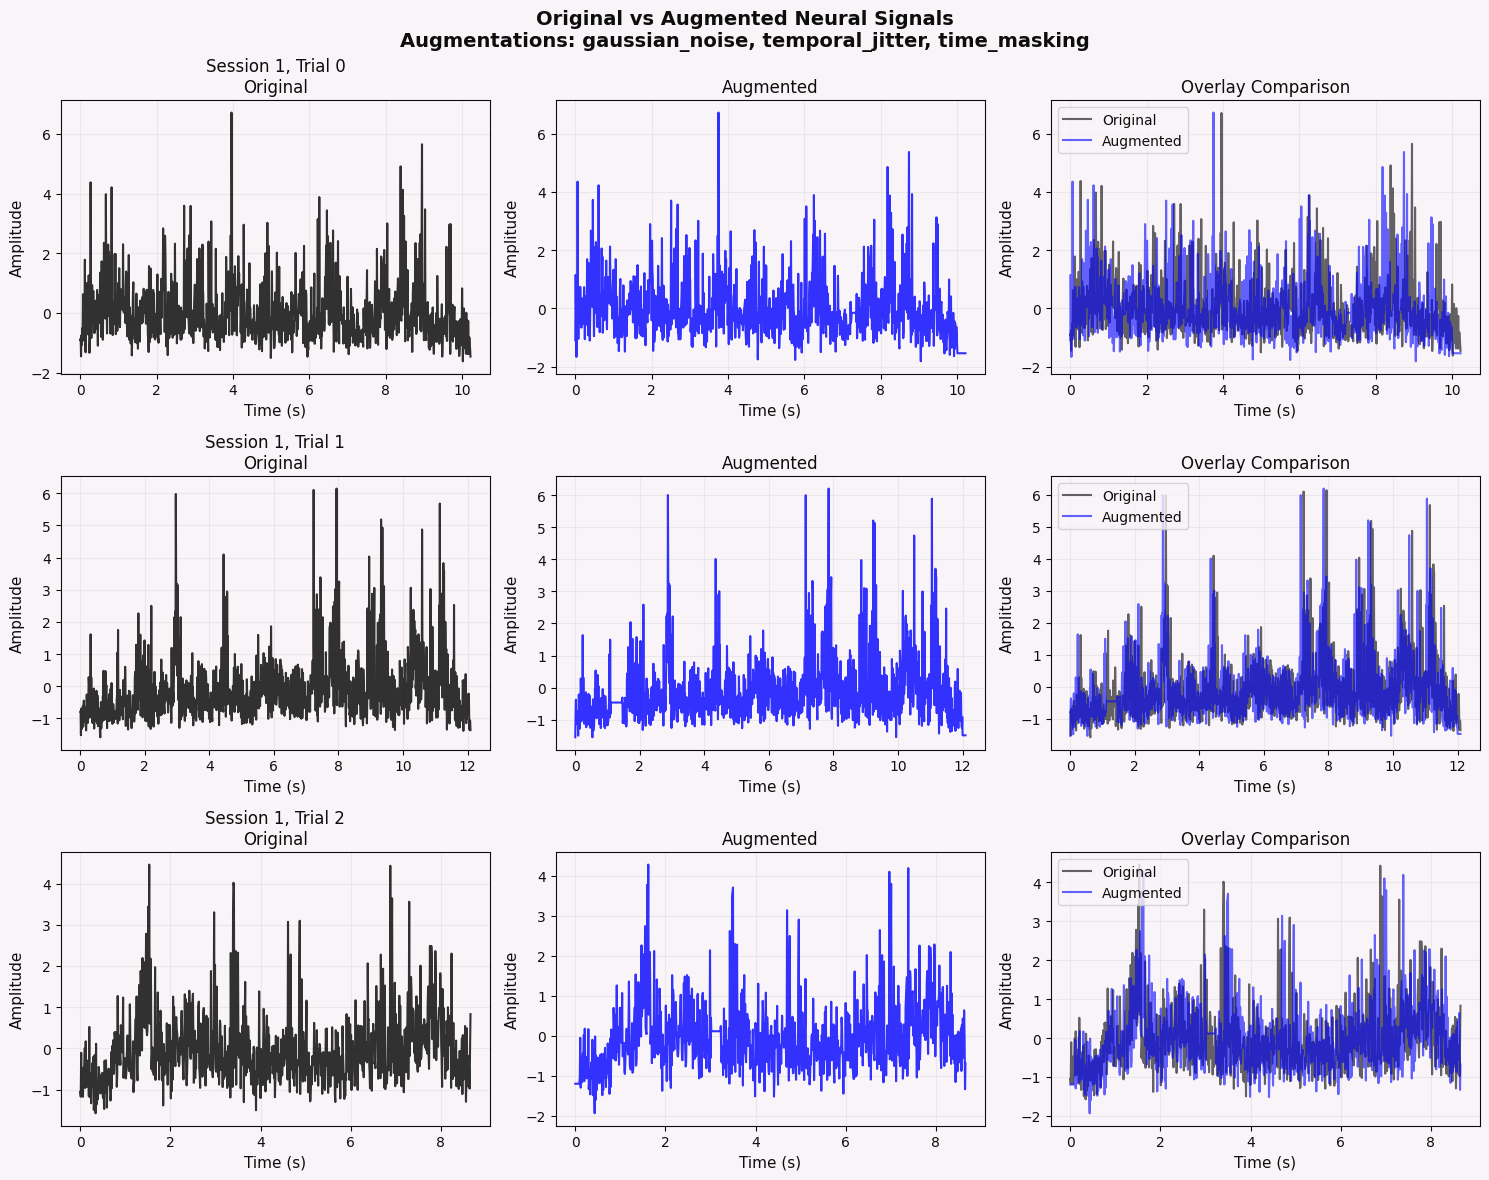

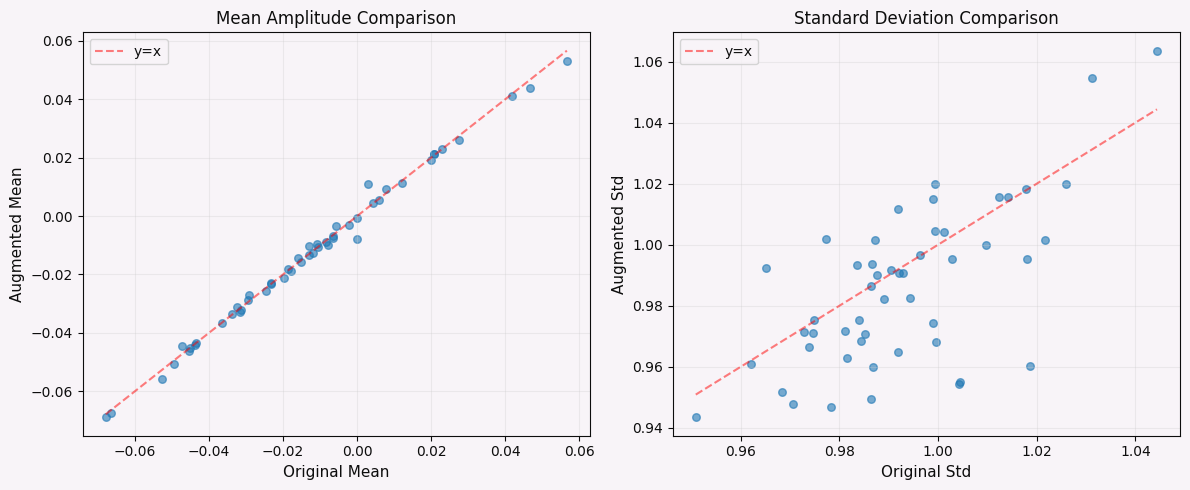

In [21]:
# Augment first 3 sessions with specific augmentations
augmentations = ['gaussian_noise', 'temporal_jitter', 'time_masking']
results = augment_sessions(
    data=data,
    session_indices=[1,2],
    augmentations_list=augmentations,
    augmentation_prob=0.7,
    max_trials_per_session=50,
    show_graph=True
)

# Or use the convenience function for first N sessions
#results = augment_first_n_sessions(data, n_sessions=5, show_graph=True)